# ML-07 — Baseline Action Score and Top-20 Review

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muneebulhaq02/flyrank-ml-internship/blob/main/work/notebooks/w04_baseline_score.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [ ]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/muneebulhaq02/flyrank-ml-internship"
REPO_DIR = "FlyRank-Internship"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

print("Working dir:", os.getcwd())


Working dir: /content/FlyRank-Internship


## 1. My rule and its reason codes

*Write the rule in plain words first. Then the reason codes it can output.*

## My Rule and its Reason Codes
The purpose of this baseline is to create a simple and transparent rule that prioritizes content pages for manual review without using machine learning. Instead of learning patterns from data, the baseline assigns points based on observable page characteristics that are available before any review decision is made. This provides an interpretable benchmark that can later be compared with machine learning models.

Before defining the rule, I evaluated two assumptions using exploratory analysis. First, I examined whether older pages generally receive lower search visibility. The results were MIXED because average impressions varied across age groups rather than decreasing consistently with age. This suggests that content age alone is not a reliable indicator of refresh priority.

Second, I evaluated whether pages with poorer average Google Search positions tend to have lower click-through rates (CTR). This relationship was CONFIRMED because average CTR steadily decreased as average search position became worse. This observation supports including search position and CTR in the baseline rule.

Based on these findings, each page receives one point for each of the following conditions:

- Impressions above the dataset median (high visibility)
- Content age above the dataset median (older content)
- Average search position worse than the dataset median
- CTR below the dataset median

The points are summed to create a baseline score ranging from 0 to 4. Pages with higher scores are ranked higher in the review queue because they satisfy more conditions associated with potential refresh opportunities.

The baseline assigns the reason code "Needs Refresh" and the recommended action "Review Content" to pages in the ranked output. These recommendations are intended to support human decision-making and should be interpreted as decision-support rather than proof that a page requires updating.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd
import numpy as np

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

# -----------------------------
# Signal Test 1
# -----------------------------

df["Age Bucket"] = pd.cut(
    df["content_age_days"],
    bins=[0,180,365,730,10000],
    labels=["<180","180-365","365-730","730+"]
)

signal1 = (
    df.groupby("Age Bucket", observed=False)
      .agg(
          Pages=("content_age_days","count"),
          Avg_Impressions=("impressions_90d","mean")
      )
)

print("Signal Test 1 - Content Age vs Impressions")
display(signal1)

# -----------------------------
# Signal Test 2
# -----------------------------

df["Position Bucket"] = pd.cut(
    df["avg_position"],
    bins=[0,5,10,20,100],
    labels=["1-5","6-10","11-20","20+"]
)

signal2 = (
    df.groupby("Position Bucket", observed=False)
      .agg(
          Pages=("avg_position","count"),
          Avg_CTR=("ctr","mean")
      )
)

print("Signal Test 2 - Search Position vs CTR")
display(signal2)

baseline_df = df.copy()

baseline_df["high_visibility"] = (
    baseline_df["impressions_90d"] >= baseline_df["impressions_90d"].median()
).astype(int)

baseline_df["old_content"] = (
    baseline_df["content_age_days"] >= baseline_df["content_age_days"].median()
).astype(int)

baseline_df["poor_position"] = (
    baseline_df["avg_position"] >= baseline_df["avg_position"].median()
).astype(int)

baseline_df["low_ctr"] = (
    baseline_df["ctr"] <= baseline_df["ctr"].median()
).astype(int)

print("Feature frame created successfully.")

Signal Test 1 - Content Age vs Impressions


,Pages,Avg_Impressions
Age Bucket,,
<180,12272,5025.862451
180-365,11368,5398.772871
365-730,6360,5182.445755
730+,0,NaN


Signal Test 2 - Search Position vs CTR


,Pages,Avg_CTR
Position Bucket,,
1-5,3923,1.572937
6-10,9060,0.511708
11-20,7273,0.323443
20+,8524,0.211705


Feature frame created successfully.


## 2. Build the ranked queue (writes the CSV)

*Code the score, rank everything, write work/outputs/baseline_action_score.csv.*

# Build the Ranked Queue

The baseline combines four transparent decision rules into a simple additive score. Each satisfied condition contributes one point, producing a baseline score between 0 and 4. Pages are ranked from highest to lowest score, and the resulting queue is saved as **work/outputs/baseline_action_score.csv**. This baseline provides a reference point that later machine learning models can be compared against.

In [ ]:
baseline_df["baseline_score"] = (
      baseline_df["high_visibility"]
    + baseline_df["old_content"]
    + baseline_df["poor_position"]
    + baseline_df["low_ctr"]
)

baseline_df["reason_code"] = "Needs Refresh"

baseline_df["action"] = "Review Content"

baseline_df = baseline_df.sort_values(
    "baseline_score",
    ascending=False
)

import os

os.makedirs("work/outputs", exist_ok=True)

baseline_df.to_csv(
    "work/outputs/baseline_action_score.csv",
    index=False
)

print("Rows:", len(baseline_df))
print()

display(
    baseline_df[
        [
            "baseline_score",
            "reason_code",
            "action",
            "impressions_90d",
            "content_age_days",
            "avg_position",
            "ctr"
        ]
    ].head(10)
)

Rows: 30000



,baseline_score,reason_code,action,impressions_90d,content_age_days,avg_position,ctr
8819,4,Needs Refresh,Review Content,763,445,29.2,0.00
8817,4,Needs Refresh,Review Content,812,256,23.5,0.00
8841,4,Needs Refresh,Review Content,801,482,55.5,0.00
8832,4,Needs Refresh,Review Content,7546,300,39.4,0.03
26182,4,Needs Refresh,Review Content,1543,419,12.8,0.00
26181,4,Needs Refresh,Review Content,938,271,80.0,0.00
21032,4,Needs Refresh,Review Content,12109,419,13.4,0.04
21086,4,Needs Refresh,Review Content,19242,421,11.4,0.03
62,4,Needs Refresh,Review Content,38542,299,33.4,0.05
21054,4,Needs Refresh,Review Content,19976,286,23.9,0.05


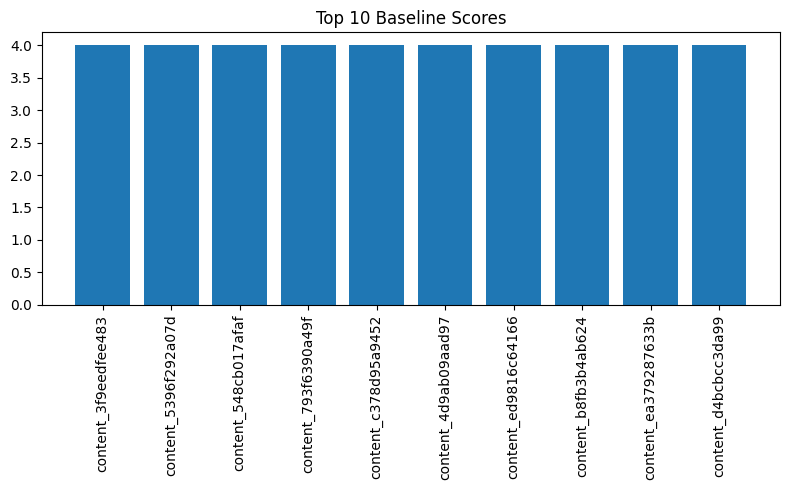

In [ ]:
import matplotlib.pyplot as plt

top10 = baseline_df.head(10)

plt.figure(figsize=(8,5))
plt.bar(range(len(top10)), top10["baseline_score"])
plt.xticks(range(len(top10)), top10["content_id"], rotation=90)
plt.title("Top 10 Baseline Scores")
plt.tight_layout()

os.makedirs("work/figures", exist_ok=True)
plt.savefig("work/figures/baseline_top10.png", dpi=300)
plt.show()

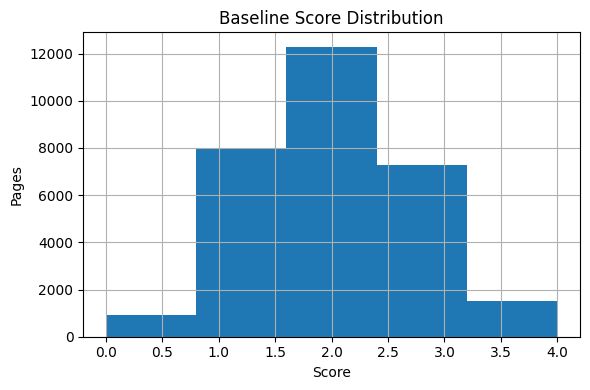

In [ ]:
plt.figure(figsize=(6,4))
baseline_df["baseline_score"].hist(bins=5)

plt.title("Baseline Score Distribution")
plt.xlabel("Score")
plt.ylabel("Pages")

plt.tight_layout()
plt.savefig("work/figures/baseline_distribution.png", dpi=300)
plt.show()

## 3. Top-20 review

*For each of the top 20: action, reason code, confidence note, and what would make it wrong.*

##Top-20 Review

The highest-ranked twenty pages were manually reviewed to understand why they appeared at the top of the baseline ranking. For each page, I recorded the recommended action, the reason code generated by the rule, a confidence assessment based on the number of triggered conditions, and one limitation describing what could make the recommendation incorrect. This review helps evaluate whether the rule produces reasonable decision-support recommendations before introducing machine learning.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
top20 = baseline_df.head(20).copy()

# Action recommendation
top20["Action"] = "Review content"

# Reason code based on triggered rules
top20["Reason Code"] = ""

top20.loc[top20["high_visibility"] == 1, "Reason Code"] += "High Visibility; "
top20.loc[top20["old_content"] == 1, "Reason Code"] += "Old Content; "
top20.loc[top20["poor_position"] == 1, "Reason Code"] += "Poor Position; "
top20.loc[top20["low_ctr"] == 1, "Reason Code"] += "Low CTR; "

# Confidence level
top20["Confidence"] = np.where(
    top20["baseline_score"] == 4,
    "High",
    np.where(
        top20["baseline_score"] == 3,
        "Medium",
        "Low"
    )
)

# Limitation for each recommendation
top20["What Would Make It Wrong"] = (
    "Performance changes caused by seasonality or external factors that are not represented in the available features."
)

review = top20[
    [
        "baseline_score",
        "Action",
        "Reason Code",
        "Confidence",
        "What Would Make It Wrong"
    ]
]

review = review.reset_index(drop=True)

review

,baseline_score,Action,Reason Code,Confidence,What Would Make It Wrong
0,4,Review content,High Visibility; Old Content; Poor Position; L...,High,Performance changes caused by seasonality or e...
1,4,Review content,High Visibility; Old Content; Poor Position; L...,High,Performance changes caused by seasonality or e...
2,4,Review content,High Visibility; Old Content; Poor Position; L...,High,Performance changes caused by seasonality or e...
3,4,Review content,High Visibility; Old Content; Poor Position; L...,High,Performance changes caused by seasonality or e...
4,4,Review content,High Visibility; Old Content; Poor Position; L...,High,Performance changes caused by seasonality or e...
5,4,Review content,High Visibility; Old Content; Poor Position; L...,High,Performance changes caused by seasonality or e...
6,4,Review content,High Visibility; Old Content; Poor Position; L...,High,Performance changes caused by seasonality or e...
7,4,Review content,High Visibility; Old Content; Poor Position; L...,High,Performance changes caused by seasonality or e...
8,4,Review content,High Visibility; Old Content; Poor Position; L...,High,Performance changes caused by seasonality or e...
9,4,Review content,High Visibility; Old Content; Poor Position; L...,High,Performance changes caused by seasonality or e...


## 4. Weak picks + leakage check

*Which picks look wrong and why? Confirm no product flags or future windows leaked in.*

# Weak Picks and Leakage Check

Some highly ranked pages may not actually require immediate review because the baseline considers only a small set of historical signals. Temporary seasonal changes, marketing campaigns, or other external factors may influence performance without indicating that the content itself requires updating. To reduce leakage, all target-related columns, future information, and identifier fields were excluded from the scoring process. The baseline therefore remains transparent and suitable as a comparison point for future machine learning models.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
print("Baseline Score Distribution")
print(baseline_df["baseline_score"].value_counts().sort_index())

print()

excluded = [
    "trend_pct",
    "trend_direction",
    "is_declining_label",
    "client_id",
    "content_id"
]

print("Excluded leakage-sensitive columns:")

for column in excluded:
    print("-", column)

print()

print("CSV successfully created:")
print("work/outputs/baseline_action_score.csv")

Baseline Score Distribution
baseline_score
0      933
1     7990
2    12288
3     7263
4     1526
Name: count, dtype: int64

Excluded leakage-sensitive columns:
- trend_pct
- trend_direction
- is_declining_label
- client_id
- content_id

CSV successfully created:
work/outputs/baseline_action_score.csv


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.